# Chess MCTS notebook

This notebook contains:
- the fixed MCTS engine
- the Black-side board/move mirroring fix
- single-position testing helpers
- model-vs-model MCTS duel helper

Run the cells in order, then set your own models and device in the setup cell.


In [7]:

import math
import time
import uuid
from collections import OrderedDict
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import chess
import chess.pgn
import numpy as np
import torch
from IPython.display import clear_output, display

import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

import numpy as np
import pandas as pd
from tqdm import tqdm
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import os
from PIL import Image
from collections import Counter
import glob
import chess
import random
# pandas display settings (kept from your original snippet)
pd.set_option('display.max_columns', None)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================================================
# GLOBAL / SHARED EVAL CACHE
# Value convention in this file:
#   positive value = good for the SIDE TO MOVE on the ORIGINAL board.
# The model is assumed to have been trained from the side-to-move perspective,
# with black positions mirrored before inference.
# =========================================================
evaluation_cache: "OrderedDict[Tuple[int, tuple], Tuple[torch.Tensor, float]]" = OrderedDict()
eval_cache_hits = 0
eval_cache_misses = 0


# =========================================================
# BOARD ENCODING
# =========================================================
def board_to_tensor(board: chess.Board) -> np.ndarray:
    tensor = np.zeros((12, 64), dtype=np.float32)

    for sq, piece in board.piece_map().items():
        layer = (piece.piece_type - 1) + (0 if piece.color == chess.WHITE else 6)
        tensor[layer][sq] = 1.0

    tensor = tensor.reshape(12, 8, 8)
    return np.flip(tensor, axis=1).copy()


# =========================================================
# MOVE HELPERS
# =========================================================
def move_to_index(move: chess.Move) -> Optional[int]:
    from_sq = move.from_square
    to_sq = move.to_square

    r0, c0 = divmod(from_sq, 8)
    r1, c1 = divmod(to_sq, 8)

    dr = r1 - r0
    dc = c1 - c0

    knight_moves = [
        (2, 1), (1, 2), (-1, 2), (-2, 1),
        (-2, -1), (-1, -2), (1, -2), (2, -1),
    ]

    if (dr, dc) in knight_moves:
        plane = 56 + knight_moves.index((dr, dc))
        return plane * 64 + from_sq

    if move.promotion is not None:
        if dc == 0:
            dir_idx = 0
        elif dc == -1:
            dir_idx = 1
        else:
            dir_idx = 2

        promo_map = {
            chess.KNIGHT: 0,
            chess.BISHOP: 1,
            chess.ROOK: 2,
            chess.QUEEN: 3,
        }
        if move.promotion not in promo_map:
            return None

        piece_idx = promo_map[move.promotion]
        plane = 64 + dir_idx * 4 + piece_idx
        return plane * 64 + from_sq

    directions = [
        (1, 0), (1, 1), (0, 1), (-1, 1),
        (-1, 0), (-1, -1), (0, -1), (1, -1),
    ]

    for dir_idx, (drd, dcd) in enumerate(directions):
        for dist in range(1, 8):
            if dr == drd * dist and dc == dcd * dist:
                plane = dir_idx * 7 + (dist - 1)
                return plane * 64 + from_sq

    return None


def mirror_move_for_black(move: chess.Move) -> chess.Move:
    return chess.Move(
        chess.square_mirror(move.from_square),
        chess.square_mirror(move.to_square),
        move.promotion,
    )


def policy_index_for_board_move(board: chess.Board, move: chess.Move) -> Optional[int]:
    """
    Convert a legal move on the ORIGINAL board into the policy index expected by
    the network. If black is to move, the board was mirrored before inference,
    so the move must be mirrored too.
    """
    if board.turn == chess.BLACK:
        move = mirror_move_for_black(move)
    return move_to_index(move)


# =========================================================
# MODEL EVALUATION
# =========================================================
def get_model_evaluation(
    model,
    board: chess.Board,
    device,
    max_cache_size: int = 200_000,
) -> Tuple[torch.Tensor, float]:
    global eval_cache_hits, eval_cache_misses, evaluation_cache

    model_id = id(model)
    board_key = board._transposition_key()
    cache_key = (model_id, board_key)

    cached = evaluation_cache.get(cache_key)
    if cached is not None:
        eval_cache_hits += 1
        evaluation_cache.move_to_end(cache_key)
        return cached

    eval_cache_misses += 1

    eval_board = board.mirror() if board.turn == chess.BLACK else board
    np_board = board_to_tensor(eval_board)
    input_tensor = torch.from_numpy(np_board).unsqueeze(0).to(device, non_blocking=True)

    with torch.inference_mode():
        policy_out, value_out = model(input_tensor)

    result = (policy_out.detach().cpu(), float(value_out.item()))
    evaluation_cache[cache_key] = result
    evaluation_cache.move_to_end(cache_key)

    while len(evaluation_cache) > max_cache_size:
        evaluation_cache.popitem(last=False)

    return result


# =========================================================
# TERMINAL VALUE
# Returned from side-to-move perspective.
# =========================================================
def terminal_value(board: chess.Board) -> Optional[float]:
    if board.is_checkmate():
        return -1.0
    if (
        board.is_stalemate()
        or board.is_insufficient_material()
        or board.can_claim_draw()
        or board.is_repetition(3)
    ):
        return 0.0
    return None


# =========================================================
# LEGAL MOVE PRIORS
# =========================================================
def get_legal_move_priors(policy_logits: torch.Tensor, board: chess.Board) -> Dict[chess.Move, float]:
    policy_scores = policy_logits.squeeze(0).flatten()
    legal_moves = list(board.legal_moves)

    indexed: List[Tuple[chess.Move, float]] = []
    for move in legal_moves:
        idx = policy_index_for_board_move(board, move)
        if idx is None or idx < 0 or idx >= policy_scores.numel():
            continue
        indexed.append((move, float(policy_scores[idx].item())))

    if not indexed:
        if not legal_moves:
            return {}
        uniform = 1.0 / len(legal_moves)
        return {move: uniform for move in legal_moves}

    logits = torch.tensor([score for _, score in indexed], dtype=torch.float32)
    probs = torch.softmax(logits, dim=0).tolist()

    priors: Dict[chess.Move, float] = {}
    for (move, _), prob in zip(indexed, probs):
        priors[move] = max(float(prob), 1e-8)

    total = sum(priors.values())
    if total <= 0:
        uniform = 1.0 / len(legal_moves)
        return {move: uniform for move in legal_moves}

    for move in list(priors.keys()):
        priors[move] /= total
    return priors


# =========================================================
# TREE NODE
# value_sum is from THIS NODE'S side-to-move perspective.
# =========================================================
class MCTSNode:
    __slots__ = (
        "board",
        "parent",
        "move",
        "prior",
        "children",
        "visit_count",
        "value_sum",
        "is_expanded",
    )

    def __init__(
        self,
        board: chess.Board,
        parent: Optional["MCTSNode"] = None,
        move: Optional[chess.Move] = None,
        prior: float = 0.0,
    ):
        self.board = board
        self.parent = parent
        self.move = move
        self.prior = float(prior)
        self.children: Dict[chess.Move, "MCTSNode"] = {}
        self.visit_count = 0
        self.value_sum = 0.0
        self.is_expanded = False

    @property
    def q_value(self) -> float:
        if self.visit_count == 0:
            return 0.0
        return self.value_sum / self.visit_count

    def expand(self, priors: Dict[chess.Move, float]) -> None:
        if self.is_expanded:
            return

        for move, prior in priors.items():
            next_board = self.board.copy(stack=False)
            next_board.push(move)
            self.children[move] = MCTSNode(
                board=next_board,
                parent=self,
                move=move,
                prior=prior,
            )

        self.is_expanded = True

    def select_child(self, c_puct: float) -> "MCTSNode":
        best_score = float("-inf")
        best_child: Optional["MCTSNode"] = None
        sqrt_parent_visits = math.sqrt(max(1, self.visit_count))

        for child in self.children.values():
            q = -child.q_value
            u = c_puct * child.prior * (sqrt_parent_visits / (1 + child.visit_count))
            score = q + u

            if score > best_score:
                best_score = score
                best_child = child

        if best_child is None:
            raise RuntimeError("select_child called on a node with no children")
        return best_child


# =========================================================
# MAIN MCTS ENGINE
# =========================================================
class MCTS:
    def __init__(
        self,
        model,
        device,
        num_simulations: int = 400,
        c_puct: float = 1.5,
        dirichlet_alpha: float = 0.3,
        dirichlet_epsilon: float = 0.25,
        max_cache_size: int = 200_000,
    ):
        self.model = model
        self.device = device
        self.num_simulations = int(num_simulations)
        self.c_puct = float(c_puct)
        self.dirichlet_alpha = float(dirichlet_alpha)
        self.dirichlet_epsilon = float(dirichlet_epsilon)
        self.max_cache_size = int(max_cache_size)
        self.root: Optional[MCTSNode] = None

        if hasattr(self.model, "eval"):
            self.model.eval()

    def reset_tree(self) -> None:
        self.root = None

    def _boards_match(self, a: chess.Board, b: chess.Board) -> bool:
        return (
            a.board_fen() == b.board_fen()
            and a.turn == b.turn
            and a.castling_rights == b.castling_rights
            and a.ep_square == b.ep_square
            and a.halfmove_clock == b.halfmove_clock
            and a.fullmove_number == b.fullmove_number
        )

    def _evaluate_node(self, node: MCTSNode) -> float:
        term = terminal_value(node.board)
        if term is not None:
            node.is_expanded = True
            return term

        policy_logits, value = get_model_evaluation(
            self.model,
            node.board,
            self.device,
            max_cache_size=self.max_cache_size,
        )
        priors = get_legal_move_priors(policy_logits, node.board)
        node.expand(priors)
        return value

    def _add_dirichlet_noise(self, node: MCTSNode) -> None:
        if not node.children:
            return
        moves = list(node.children.keys())
        noise = np.random.dirichlet([self.dirichlet_alpha] * len(moves))
        for move, n in zip(moves, noise):
            child = node.children[move]
            child.prior = (1.0 - self.dirichlet_epsilon) * child.prior + self.dirichlet_epsilon * float(n)

    def _backpropagate(self, search_path: List[MCTSNode], value: float) -> None:
        for node in reversed(search_path):
            node.visit_count += 1
            node.value_sum += value
            value = -value

    def _sync_root(self, board: chess.Board) -> None:
        if self.root is None:
            self.root = MCTSNode(board.copy(stack=False))
            return

        if self._boards_match(self.root.board, board):
            return

        for child in self.root.children.values():
            if self._boards_match(child.board, board):
                child.parent = None
                self.root = child
                return

        self.root = MCTSNode(board.copy(stack=False))

    def advance_to_move(self, move: chess.Move) -> None:
        if self.root is None:
            return
        child = self.root.children.get(move)
        if child is not None:
            child.parent = None
            self.root = child
            return

        new_board = self.root.board.copy(stack=False)
        if move in new_board.legal_moves:
            new_board.push(move)
            self.root = MCTSNode(new_board)
        else:
            self.root = None

    def search(
        self,
        board: chess.Board,
        temperature: float = 0.0,
        add_noise: bool = False,
        return_root: bool = False,
    ):
        self._sync_root(board)
        assert self.root is not None

        if not self.root.is_expanded:
            root_value = self._evaluate_node(self.root)
            if self.root.visit_count == 0:
                self.root.visit_count = 1
                self.root.value_sum = root_value

        if add_noise:
            self._add_dirichlet_noise(self.root)

        for _ in range(self.num_simulations):
            node = self.root
            search_path = [node]

            while node.is_expanded and node.children:
                node = node.select_child(self.c_puct)
                search_path.append(node)

            value = self._evaluate_node(node)
            self._backpropagate(search_path, value)

        if return_root:
            return self.root

        move = self.select_move(temperature=temperature)
        return move

    def select_move(self, temperature: float = 0.0) -> Optional[chess.Move]:
        if self.root is None or not self.root.children:
            return None

        moves = list(self.root.children.keys())
        visits = np.array([self.root.children[m].visit_count for m in moves], dtype=np.float64)

        if temperature <= 1e-8:
            return moves[int(np.argmax(visits))]

        visits = np.maximum(visits, 1e-12)
        weights = visits ** (1.0 / temperature)
        probs = weights / weights.sum()
        idx = int(np.random.choice(len(moves), p=probs))
        return moves[idx]

    def get_move_distribution(self, board: chess.Board) -> List[Dict[str, float]]:
        root = self.search(board, temperature=0.0, add_noise=False, return_root=True)
        total_visits = sum(child.visit_count for child in root.children.values())
        result = []
        for move, child in sorted(root.children.items(), key=lambda x: x[1].visit_count, reverse=True):
            result.append(
                {
                    "move": move,
                    "visits": child.visit_count,
                    "prior": child.prior,
                    "q_value": child.q_value,
                    "visit_fraction": child.visit_count / max(1, total_visits),
                }
            )
        return result


# =========================================================
# COMPAT WRAPPERS
# =========================================================
def run_mcts(
    board: chess.Board,
    model,
    device,
    num_simulations: int = 400,
    c_puct: float = 1.5,
    add_noise: bool = False,
    dirichlet_alpha: float = 0.3,
    dirichlet_epsilon: float = 0.25,
):
    engine = MCTS(
        model=model,
        device=device,
        num_simulations=num_simulations,
        c_puct=c_puct,
        dirichlet_alpha=dirichlet_alpha,
        dirichlet_epsilon=dirichlet_epsilon,
    )
    return engine.search(board, add_noise=add_noise, return_root=True)


def get_best_move(
    board_state: chess.Board,
    model,
    device,
    num_simulations: int = 400,
    c_puct: float = 1.5,
    temperature: float = 0.0,
    add_noise: bool = False,
) -> Optional[chess.Move]:
    engine = MCTS(
        model=model,
        device=device,
        num_simulations=num_simulations,
        c_puct=c_puct,
    )
    return engine.search(board_state, temperature=temperature, add_noise=add_noise)


def get_move_distribution(
    board_state: chess.Board,
    model,
    device,
    num_simulations: int = 400,
    c_puct: float = 1.5,
):
    engine = MCTS(
        model=model,
        device=device,
        num_simulations=num_simulations,
        c_puct=c_puct,
    )
    return engine.get_move_distribution(board_state)


# =========================================================
# DUEL HELPER
# =========================================================
def run_model_duel_mcts(
    model_a,
    model_b,
    device,
    num_games: int = 10,
    simulations: int = 200,
    c_puct: float = 1.5,
    save_dir: str = "pgn_exports",
    start_fen: str = "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0",
    move_delay: float = 0.0,
    reuse_tree: bool = True,
):
    results = {"Model_A": 0, "Model_B": 0, "Draws": 0}

    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    model_a.eval()
    model_b.eval()
    all_games = []

    for game_num in range(num_games):
        board = chess.Board(start_fen)
        a_is_white = (game_num % 2 == 0)

        searcher_a = MCTS(model_a, device, num_simulations=simulations, c_puct=c_puct)
        searcher_b = MCTS(model_b, device, num_simulations=simulations, c_puct=c_puct)

        game = chess.pgn.Game()
        game.headers["Event"] = "Model Duel"
        game.headers["Site"] = "Local"
        game.headers["Date"] = datetime.now().strftime("%Y.%m.%d")
        game.headers["Round"] = str(game_num + 1)
        game.headers["White"] = "Model_A" if a_is_white else "Model_B"
        game.headers["Black"] = "Model_B" if a_is_white else "Model_A"
        game.headers["FEN"] = start_fen
        game.headers["SetUp"] = "1"

        node = game
        move_list_uci = []

        while not board.is_game_over() and not board.can_claim_draw():
            clear_output(wait=True)

            print(f"=== THE GREAT DUEL: GAME {game_num + 1} of {num_games} ===")
            print(f"Model_A is playing as: {'WHITE' if a_is_white else 'BLACK'}")
            print(f"Current Score -> A: {results['Model_A']} | B: {results['Model_B']} | Draws: {results['Draws']}\n")

            display(board)
            print(f"\nCurrent FEN: {board.fen()}\n")

            is_ai_a_turn = (board.turn == chess.WHITE) == a_is_white
            current_name = "Model_A" if is_ai_a_turn else "Model_B"
            current_searcher = searcher_a if is_ai_a_turn else searcher_b

            print(f"{current_name} is thinking (MCTS, {simulations} simulations, c_puct={c_puct})...")

            with torch.inference_mode():
                move = current_searcher.search(board, temperature=0.0, add_noise=False)

            if move is None or move not in board.legal_moves:
                print(f"Error: {current_name} failed to produce a legal move! Returned: {move}")
                break

            move_list_uci.append(move.uci())
            board.push(move)
            node = node.add_variation(move)

            if reuse_tree:
                searcher_a.advance_to_move(move)
                searcher_b.advance_to_move(move)
            else:
                searcher_a.reset_tree()
                searcher_b.reset_tree()

            if move_delay > 0:
                time.sleep(move_delay)

        clear_output(wait=True)
        display(board)
        print(f"\nFinal FEN: {board.fen()}\n")

        outcome = board.outcome(claim_draw=True)
        if outcome is None or outcome.winner is None:
            results["Draws"] += 1
            result_str = "1/2-1/2"
            print(f"Game {game_num + 1} Result: DRAW")
        elif (outcome.winner == chess.WHITE and a_is_white) or (outcome.winner == chess.BLACK and not a_is_white):
            results["Model_A"] += 1
            result_str = "1-0" if a_is_white else "0-1"
            print(f"Game {game_num + 1} Result: MODEL_A WINS!")
        else:
            results["Model_B"] += 1
            result_str = "0-1" if a_is_white else "1-0"
            print(f"Game {game_num + 1} Result: MODEL_B WINS!")

        game.headers["Result"] = result_str
        game.headers["Termination"] = outcome.termination.name if outcome is not None else "UNKNOWN"
        game.headers["Model_A_Color"] = "White" if a_is_white else "Black"
        game.headers["SearchType"] = "MCTS"
        game.headers["Simulations"] = str(simulations)
        game.headers["CPUCT"] = str(c_puct)
        game.headers["TreeReuse"] = str(reuse_tree)

        all_games.append(game)

        unique_name = f"duel_game_{game_num + 1}_{datetime.now().strftime('%Y%m%d_%H%M%S')}_{uuid.uuid4().hex[:8]}.pgn"
        game_file = save_path / unique_name
        with open(game_file, "w", encoding="utf-8") as f:
            exporter = chess.pgn.FileExporter(f)
            game.accept(exporter)

        print(f"Saved PGN: {game_file}")
        print("Moves:", " ".join(move_list_uci))

        if move_delay > 0:
            time.sleep(move_delay)

    combined_name = f"duel_match_{datetime.now().strftime('%Y%m%d_%H%M%S')}_{uuid.uuid4().hex[:8]}.pgn"
    combined_file = save_path / combined_name
    with open(combined_file, "w", encoding="utf-8") as f:
        for g in all_games:
            exporter = chess.pgn.FileExporter(f)
            g.accept(exporter)
            f.write("\n\n")

    print("\n=== DUEL COMPLETE ===")
    print(f"Final Score -> A: {results['Model_A']} | B: {results['Model_B']} | Draws: {results['Draws']}")
    print(f"Combined PGN saved to: {combined_file}")
    return results, str(combined_file)


In [3]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x 
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual 
        out = F.relu(out)
        return out

# 2. The DUAL-HEAD Chess Neural Network
class ChessResNet(nn.Module):
    def __init__(self, num_blocks=10, hidden_channels=128):
        super(ChessResNet, self).__init__()
        
        self.start_conv = nn.Conv2d(12, hidden_channels, kernel_size=3, padding=1)
        self.start_bn = nn.BatchNorm2d(hidden_channels)
        self.res_blocks = nn.ModuleList([ResBlock(hidden_channels) for _ in range(num_blocks)])
        
        # --- FIXED POLICY HEAD (76 Planes) ---
        self.policy_conv = nn.Conv2d(hidden_channels, 76, kernel_size=1) 
        self.policy_bn = nn.BatchNorm2d(76)
        
        # 76 planes * 8 * 8 squares = 4864 nodes
        self.policy_fc = nn.Linear(76 * 8 * 8, 4864) 
        
        # --- Value Head ---
        self.eval_conv = nn.Conv2d(hidden_channels, 1, kernel_size=1)
        self.eval_bn = nn.BatchNorm2d(1)
        self.eval_fc1 = nn.Linear(8 * 8, 64) 
        self.eval_fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.start_bn(self.start_conv(x)))
        for block in self.res_blocks:
            x = block(x)
            
        # Policy output
        p = F.relu(self.policy_bn(self.policy_conv(x)))
        p = p.view(-1, 4864) # Flatten to the correct 4864 size
        policy_out = self.policy_fc(p) 
        
        # Value output
        v = F.relu(self.eval_bn(self.eval_conv(x)))
        v = v.view(-1, 64) 
        v = F.relu(self.eval_fc1(v))
        v = self.eval_fc2(v)
        value_out = torch.tanh(v) 
        
        return policy_out, value_out
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = torch.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + residual
        out = torch.relu(out)
        return out


class AlphaZeroChessNet(nn.Module):
    def __init__(self, input_channels=12, num_blocks=12, channels=128, policy_size=4864):
        super().__init__()

        self.input_conv = nn.Conv2d(input_channels, channels, kernel_size=3, padding=1, bias=False)
        self.input_bn = nn.BatchNorm2d(channels)

        self.res_tower = nn.Sequential(*[ResidualBlock(channels) for _ in range(num_blocks)])

        self.policy_conv = nn.Conv2d(channels, 32, kernel_size=1, bias=False)
        self.policy_bn = nn.BatchNorm2d(32)
        self.policy_fc = nn.Linear(32 * 8 * 8, policy_size)

        # Match checkpoint: 3 channels, not 8
        self.value_conv = nn.Conv2d(channels, 3, kernel_size=1, bias=False)
        self.value_bn = nn.BatchNorm2d(3)
        self.value_fc1 = nn.Linear(3 * 8 * 8, 256)
        self.value_fc2 = nn.Linear(256, 1)

    def forward(self, x):
        x = self.input_conv(x)
        x = self.input_bn(x)
        x = torch.relu(x)

        x = self.res_tower(x)

        p = self.policy_conv(x)
        p = self.policy_bn(p)
        p = torch.relu(p)
        p = p.view(p.size(0), -1)
        policy_logits = self.policy_fc(p)

        v = self.value_conv(x)
        v = self.value_bn(v)
        v = torch.relu(v)
        v = v.view(v.size(0), -1)
        v = torch.relu(self.value_fc1(v))
        value = torch.tanh(self.value_fc2(v)).squeeze(1)

        return policy_logits, value


device = "cuda" if torch.cuda.is_available() else "cpu"

import torch

# ===== DEVICE =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== INIT MODELS =====
model_sakory = AlphaZeroChessNet()   # replace with your model class
modeltunedv2 = ChessResNet()

# ===== LOAD WEIGHTS =====
checkpoint = torch.load(r"Models\sakory_v3.pth", map_location=device, weights_only=True)

state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
model_sakory.load_state_dict(state_dict)

model_sakory.eval()

modeltunedv2.load_state_dict(
    torch.load(
        r"Models/chess_model_v3.pth",
        map_location=device,
        weights_only=True
    )
)

# ===== OPTIONAL (speed boost) =====
model_sakory = torch.compile(model_sakory, backend="aot_eager")
modeltunedv2 = torch.compile(modeltunedv2, backend="aot_eager")

# ===== EVAL MODE =====
model_sakory.to(device).eval()
modeltunedv2.to(device).eval()


OptimizedModule(
  (_orig_mod): ChessResNet(
    (start_conv): Conv2d(12, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (start_bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (res_blocks): ModuleList(
      (0-9): 10 x ResBlock(
        (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (policy_conv): Conv2d(128, 76, kernel_size=(1, 1), stride=(1, 1))
    (policy_bn): BatchNorm2d(76, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (policy_fc): Linear(in_features=4864, out_features=4864, bias=True)
    (eval_conv): Conv2d(128, 1, kernel_size=(1, 1), stride=(1, 1))
    (eval_bn): BatchNorm2d(1, eps

In [ ]:
# Single-position test
board = chess.Board("r2q2k1/ppp2rp1/3b1n1p/8/3Q4/2N4P/PP3PP1/R1B1R1K1 b - - 0 15")
searcher = MCTS(modeltunedv2, device, num_simulations=400, c_puct=2.0)

best_move = searcher.search(board)
print("Best move:", best_move)
print("Top moves:")
for row in searcher.get_move_distribution(board)[:10]:
    print(row)


Best move: d6h2
Top moves:
{'move': Move.from_uci('d6h2'), 'visits': 706, 'prior': 0.007546928176331302, 'q_value': -0.9273319199428004, 'visit_fraction': 0.8825}
{'move': Move.from_uci('d8d7'), 'visits': 51, 'prior': 0.5813345855781306, 'q_value': 0.07116474448383658, 'visit_fraction': 0.06375}
{'move': Move.from_uci('d8f8'), 'visits': 12, 'prior': 0.08415596854959821, 'q_value': -0.00037099576244751614, 'visit_fraction': 0.015}
{'move': Move.from_uci('f7d7'), 'visits': 7, 'prior': 0.041333481290191994, 'q_value': -0.008806530253163405, 'visit_fraction': 0.00875}
{'move': Move.from_uci('b7b6'), 'visits': 4, 'prior': 0.04475969035089678, 'q_value': 0.04559856478590518, 'visit_fraction': 0.005}
{'move': Move.from_uci('a7a6'), 'visits': 4, 'prior': 0.0393081490069193, 'q_value': 0.06724037602543831, 'visit_fraction': 0.005}
{'move': Move.from_uci('c7c6'), 'visits': 3, 'prior': 0.034090287670639714, 'q_value': 0.0901911308368047, 'visit_fraction': 0.00375}
{'move': Move.from_uci('c7c5'), 

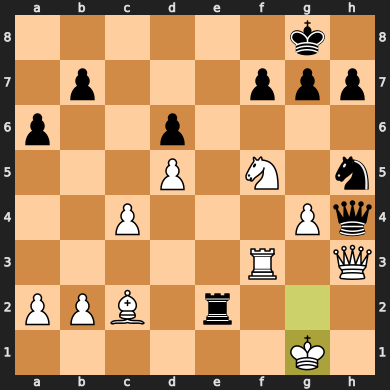


Final FEN: 6k1/1p3ppp/p2p4/3P1N1n/2P3Pq/5R1Q/PPB1r3/6K1 b - - 8 34

Game 1 Result: DRAW
Saved PGN: pgn_exports\duel_game_1_20260320_021056_c4811ae7.pgn
Moves: e2e4 c7c5 g1f3 d7d6 d2d4 c5d4 f3d4 g8f6 b1c3 a7a6 f1e2 e7e5 d4b3 f8e7 e1g1 e8g8 c1e3 c8e6 f2f4 e5f4 f1f4 b8c6 c3d5 e6d5 e4d5 c6e5 c2c4 f6d7 f4f2 a8c8 a1c1 e7g5 e3g5 d8g5 c1c3 d7f6 d1d4 f8e8 h2h3 e5d7 e2d3 e8e1 f2f1 c8e8 d4f2 e1f1 f2f1 d7e5 d3c2 e5g6 b3d4 g6f4 c3f3 f6h5 g2g4 g5h4 d4f5 f4h3 f1h3 e8e1 g1g2 e1e2 g2g1 e2e1 g1g2 e1e2 g2g1

=== DUEL COMPLETE ===
Final Score -> A: 0 | B: 0 | Draws: 1
Combined PGN saved to: pgn_exports\duel_match_20260320_021056_dd6c9a49.pgn
Returned PGN path: pgn_exports\duel_match_20260320_021056_dd6c9a49.pgn
Results: {'Model_A': 0, 'Model_B': 0, 'Draws': 1}


In [8]:
# MCTS match test
duel_results, pgn_path = run_model_duel_mcts(
    model_a=model_sakory,
    model_b=modeltunedv2,
    device=device,
    num_games=1,
    simulations=400,
    c_puct=2.0,
    save_dir="pgn_exports",
    move_delay=0.0,
    reuse_tree=True,
)
print("Returned PGN path:", pgn_path)
print("Results:", duel_results)
